# AbSynth Token Embedding Visualization

Visualizes the learned amino acid token embeddings from AbSynth-A or AbSynth-M
using PCA and t-SNE, color-coded by hydropathy class.

Amino acids that are chemically similar should cluster together if the model
has learned meaningful biochemical representations.

**Run all cells top to bottom. Set your model choice in Cell 2.**

## Cell 1 — Imports & paths

In [29]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Resolve paths relative to notebook location (this notebook lives at repo root)
REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, REPO_ROOT)

from absynth import AbSynthA, AbSynthM

OUTPUT_DIR = "embedding_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")

Repo root: c:\Users\User\OneDrive\Desktop\PyProject\github-repo


## Cell 2 — Model selector

Switch between AbSynth-A (autoregressive) and AbSynth-M (masked).

In [30]:
MODEL_TYPE = "autoregressive"   # "autoregressive" or "masked"

if MODEL_TYPE == "autoregressive":
    MODEL_PATH = os.path.join(REPO_ROOT, "absynth", "trained_models", "absynth-a")
    MODEL_LABEL = "AbSynth-A"
else:
    MODEL_PATH = os.path.join(REPO_ROOT, "absynth", "trained_models", "absynth-m")
    MODEL_LABEL = "AbSynth-M"

TOKENIZER_PATH = os.path.join(REPO_ROOT, "absynth", "tokenizer")
TSNE_SEED      = 3

print(f"Model      : {MODEL_LABEL}")
print(f"Model path : {MODEL_PATH}")

Model      : AbSynth-A
Model path : c:\Users\User\OneDrive\Desktop\PyProject\github-repo\absynth\trained_models\absynth-a


## Cell 3 — Load model and extract amino acid embeddings

In [31]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

if MODEL_TYPE == "autoregressive":
    absynth_model = AbSynthA(MODEL_PATH, TOKENIZER_PATH)
else:
    absynth_model = AbSynthM(MODEL_PATH, TOKENIZER_PATH)

tokenizer = absynth_model.tokenizer
emb_matrix = absynth_model.model.get_input_embeddings().weight.detach().cpu()

# Extract one embedding vector per amino acid
weights, labels = [], []
for aa in AMINO_ACIDS:
    ids = tokenizer.encode(aa, add_special_tokens=False)
    if ids:
        weights.append(emb_matrix[ids[0]].numpy())
        labels.append(aa)

weights = np.array(weights)
print(f"Embedding matrix : {weights.shape}")
print(f"Amino acids      : {labels}")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'RobertaTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'RobertaTokenizerFast'.


AbSynth-A loaded | device=cuda | vocab=25 | params=21,874,176
Embedding matrix : (20, 768)
Amino acids      : ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


---
## Cell 4 — Sequence embeddings on Thera-SAbDab therapeutic antibodies

Beyond single amino-acid tokens, test whether AbSynth produces meaningful
*sequence*-level embeddings on real heavy-chain variable domains from
[Thera-SAbDab](https://opig.stats.ox.ac.uk/webapps/sabdab-sabpred/therasabdab/search/)
(the Therapeutic Structural Antibody Database) — one row per WHO-recognized
antibody therapeutic. Data downloaded to `data/TheraSAbDab_SeqStruc_OnlineDownload.csv`.

Both models are trained specifically on **human** antibody sequences, so
instead of antibody format/type, color points by **species/humanization
origin** (fully human, humanised, chimeric, murine, other species) parsed
from the `Genetics` column — and compare AbSynth-A vs AbSynth-M side by side
via t-SNE to see whether either embedding space separates human-like
sequences from non-human ones.

In [32]:
THERASABDAB_CSV = os.path.join(REPO_ROOT, "data", "TheraSAbDab_SeqStruc_OnlineDownload.csv")
GENETICS_COL = "Genetics (Bispecifics delimited with semicolon)"

def classify_species(raw):
    """Collapse the free-text Genetics column into a clean species/origin label."""
    if not isinstance(raw, str):
        return "Unknown"
    first = raw.split(";")[0].strip().lower()
    if first in ("na", ""):
        return "Unknown"
    if "genetically human" in first:
        return "Human"
    if "murine" in first:
        return "Murine"
    if "chimeric" in first and "human" in first:
        return "Chimeric + Humanised"
    if "chimeric" in first:
        return "Chimeric"
    if "humanised" in first or "humanized" in first:
        return "Humanised"
    if any(sp in first for sp in ["canin", "felin", "llama", "alpaca", "camel"]):
        return "Other species"
    return "Other/Unclassified"

thera_df = pd.read_csv(THERASABDAB_CSV)
thera_df = thera_df[thera_df["HeavySequence"].notna() & (thera_df["HeavySequence"].str.lower() != "na")]
thera_df = thera_df.drop_duplicates(subset="HeavySequence").reset_index(drop=True)
thera_df["Species"] = thera_df[GENETICS_COL].apply(classify_species)

print(f"Therapeutics with a usable heavy-chain sequence: {len(thera_df)}")
print(thera_df["Species"].value_counts())
thera_df[["Therapeutic", "Species", "HeavySequence"]].head()

Therapeutics with a usable heavy-chain sequence: 1047
Species
Human                   432
Humanised               393
Chimeric + Humanised    107
Chimeric                 60
Unknown                  25
Murine                   21
Other species             9
Name: count, dtype: int64


,Therapeutic,Species,HeavySequence
0,Abagovomab,Murine,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...
1,Abazistobart,Chimeric + Humanised,EVKLVESGGGLVQPGGSLRLSCAASGFAFSSYDMSWVRQAPGKRLE...
2,Abciximab,Chimeric,EVQLQQSGTVLARPGASVKMSCEASGYTFTNYWMHWVKQRPGQGLE...
3,Abelacimab,Human,QVQLLESGGGLVQPGGSLRLSCAASGFTFSTAAMSWVRQAPGKGLE...
4,Abiprubart,Humanised,QVQLVQSGAEVKKPGASVKVSCKASGYTFTNYWMHWVRQAPGQRLE...


In [33]:
MODEL_A_PATH = os.path.join(REPO_ROOT, "absynth", "trained_models", "absynth-a")
MODEL_M_PATH = os.path.join(REPO_ROOT, "absynth", "trained_models", "absynth-m")

absynth_a = AbSynthA(MODEL_A_PATH, TOKENIZER_PATH)
absynth_m = AbSynthM(MODEL_M_PATH, TOKENIZER_PATH)

thera_sequences = thera_df["HeavySequence"].tolist()
thera_embeddings_a = absynth_a.embed(thera_sequences)
thera_embeddings_m = absynth_m.embed(thera_sequences)

print(f"AbSynth-A embedding matrix: {thera_embeddings_a.shape}  (n_sequences, hidden_size)")
print(f"AbSynth-M embedding matrix: {thera_embeddings_m.shape}  (n_sequences, hidden_size)")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'RobertaTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'RobertaTokenizerFast'.


AbSynth-A loaded | device=cuda | vocab=25 | params=21,874,176


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'RobertaTokenizer'.


AbSynth-M loaded | device=cuda | vocab=25 | params=17,745,433


Embedding: 100%|██████████| 1047/1047 [00:02<00:00, 439.58it/s]

AbSynth-A embedding matrix: (1047, 768)  (n_sequences, hidden_size)
AbSynth-M embedding matrix: (1047, 768)  (n_sequences, hidden_size)


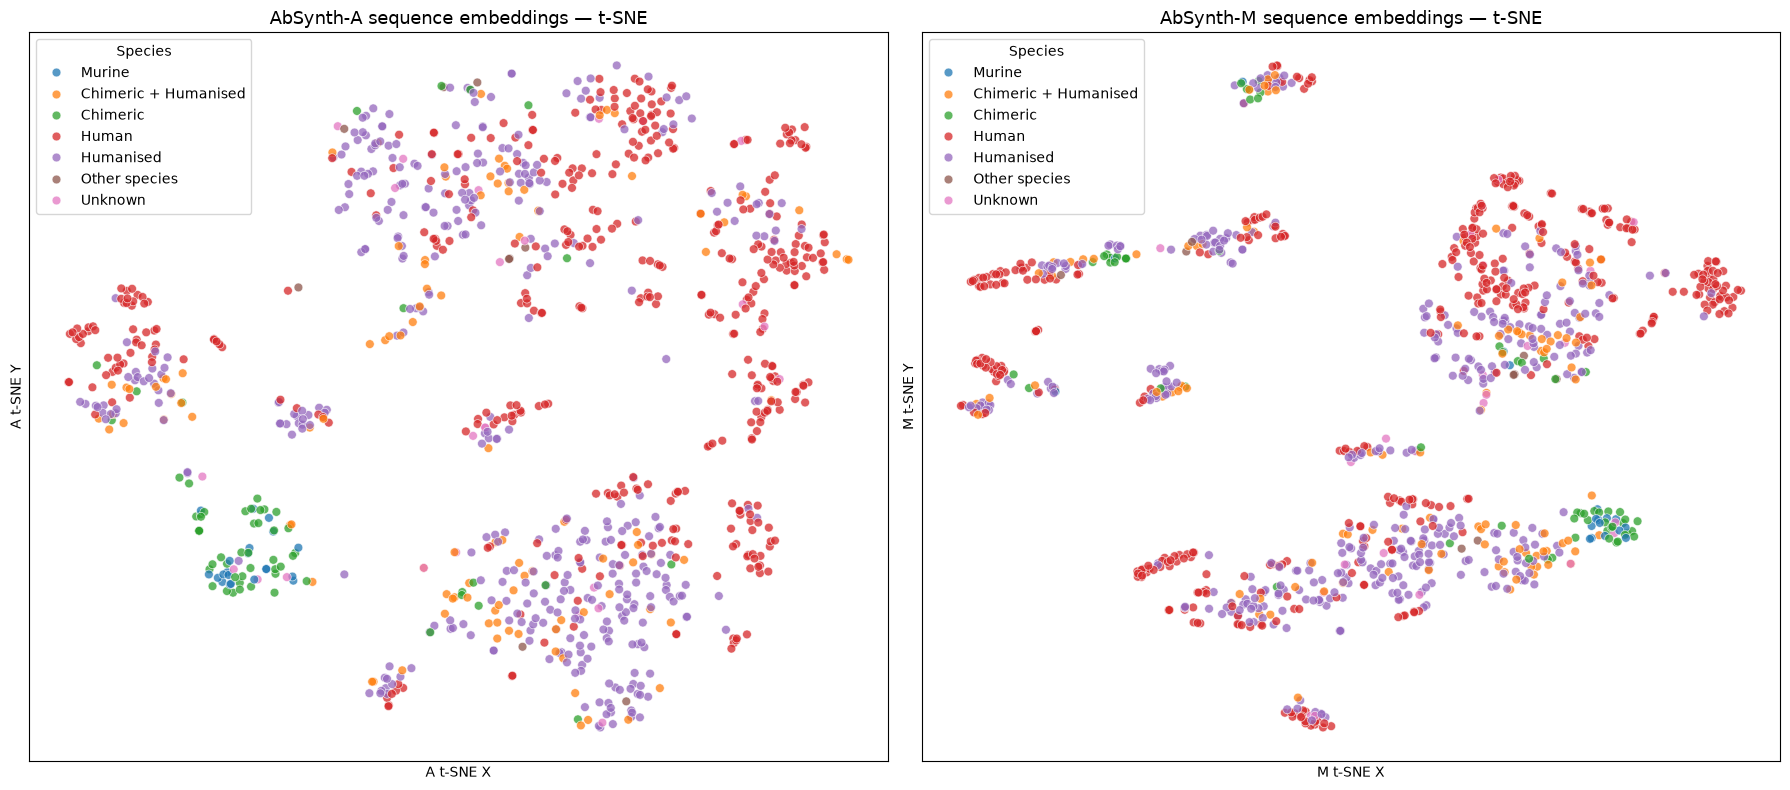

Saved → embedding_output\therasabdab_embeddings_a_vs_m_tsne.pdf


In [34]:
tsne_a = TSNE(n_components=2, perplexity=30, random_state=TSNE_SEED).fit_transform(thera_embeddings_a)
tsne_m = TSNE(n_components=2, perplexity=30, random_state=TSNE_SEED).fit_transform(thera_embeddings_m)

thera_plot_df = pd.DataFrame({
    "Therapeutic": thera_df["Therapeutic"],
    "Species":     thera_df["Species"],
    "A t-SNE X":   tsne_a[:, 0],
    "A t-SNE Y":   tsne_a[:, 1],
    "M t-SNE X":   tsne_m[:, 0],
    "M t-SNE Y":   tsne_m[:, 1],
})

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (x_col, y_col), title in [
    (axes[0], ("A t-SNE X", "A t-SNE Y"), "AbSynth-A"),
    (axes[1], ("M t-SNE X", "M t-SNE Y"), "AbSynth-M"),
]:
    sns.scatterplot(data=thera_plot_df, x=x_col, y=y_col, hue="Species", s=40, alpha=0.75, ax=ax)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title} sequence embeddings — t-SNE", fontsize=13)

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, "therasabdab_embeddings_a_vs_m_tsne.pdf")
plt.savefig(out, dpi=400, transparent=True)
plt.show()
plt.close("all")
print(f"Saved → {out}")